In [21]:
from cartopy.io.shapereader import Reader
from cartopy.feature import ShapelyFeature
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import pyart
from netCDF4 import Dataset
from datetime import datetime, timedelta
from metpy.units import units

In [14]:
# ncfile = Dataset('/glade/derecho/scratch/mawilson/FOG_WPS/run_wps_tblmtn/geo_em.d02_jk')
# ncfile2 = Dataset('/glade/derecho/scratch/mawilson/FOG_WPS/run_wps_tblmtn/geo_em.d01.nc')

ncfile = Dataset('/glade/campaign/ral/aap/mawilson/nature_runs/IOP4/final_nature/wrfout_d01_2022-07-19_03:00:00')
ncfile2 = Dataset('/glade/campaign/ral/aap/mawilson/nature_runs/IOP4/final_nature/wrfout_d02_2022-07-19_03:00:00')

In [15]:
lon = ncfile.variables['XLONG'][:]
lat = ncfile.variables['XLAT'][:]
hgt = ncfile.variables['HGT'][:]

lon2 = ncfile2.variables['XLONG'][:]
lat2 = ncfile2.variables['XLAT'][:]
hgt2 = ncfile2.variables['HGT'][:]
#print(ncfile2.variables)

In [16]:
dt = datetime(2021,6,4,10)
duration=1
#Let's build a network of ~20 stations centered on KCVG and KLUK
#First, add the indicies for KCVG and KLUK

st_id = ['KCVG','KLUK','KI69','KI67','KI68','KOXD','KHLB','KIMS','KILN','KMWO','KFGX']

st_xind = [370,377,374,394,417,421,403,338,414,424,315]

st_yind = [459,481,499,450,495,449,408,390,536,483,540] 

#Elevation (IN FEET)
elev = [860,482,843,584,989,1041,975,819,1076,649,912]
#Get verification network locations
Obs_TT = np.zeros((duration,len(elev)))
Obs_R2T = np.zeros((duration,len(elev)))
Obs_ST = np.zeros((duration,len(elev)))
Obs_VT = np.zeros((duration,len(elev)))
Obs_lon = np.zeros((duration,len(elev)))
Obs_lat = np.zeros((duration,len(elev)))
for i in range(1):
    ObsFile = np.genfromtxt('SavedObs'+dt.isoformat()[0:10]+dt.isoformat()[11:13]+'.csv',delimiter=',', skip_header=1)
    ObsFileStr = np.genfromtxt('SavedObs'+dt.isoformat()[0:10]+dt.isoformat()[11:13]+'.csv',delimiter=',', 
                               skip_header=1,usecols=(0),dtype='str')
    #print(time_list[i])
    ind_id = []
    for j in range(len(st_id)):
        #print(ObsFileStr[ObsFileStr==st_id[j]])
        ind_id.append(np.where(ObsFileStr==st_id[j])[0][0])

    Obs_Ti = ObsFile[ind_id,1]
    Obs_R2i = ObsFile[ind_id,5]
    Obs_Si = ObsFile[ind_id,6]
    Obs_Vi = ObsFile[ind_id,11]
    Obs_loni = ObsFile[ind_id,8]
    Obs_lati = ObsFile[ind_id,9]
    Obs_TT[i,:]=Obs_Ti
    Obs_R2T[i,:]=Obs_R2i
    Obs_ST[i,:]=Obs_Si
    Obs_VT[i,:]=Obs_Vi
    Obs_lon[i,:]=Obs_loni
    Obs_lat[i,:]=Obs_lati
Obs_R2T[Obs_R2T>1.05]=np.nan

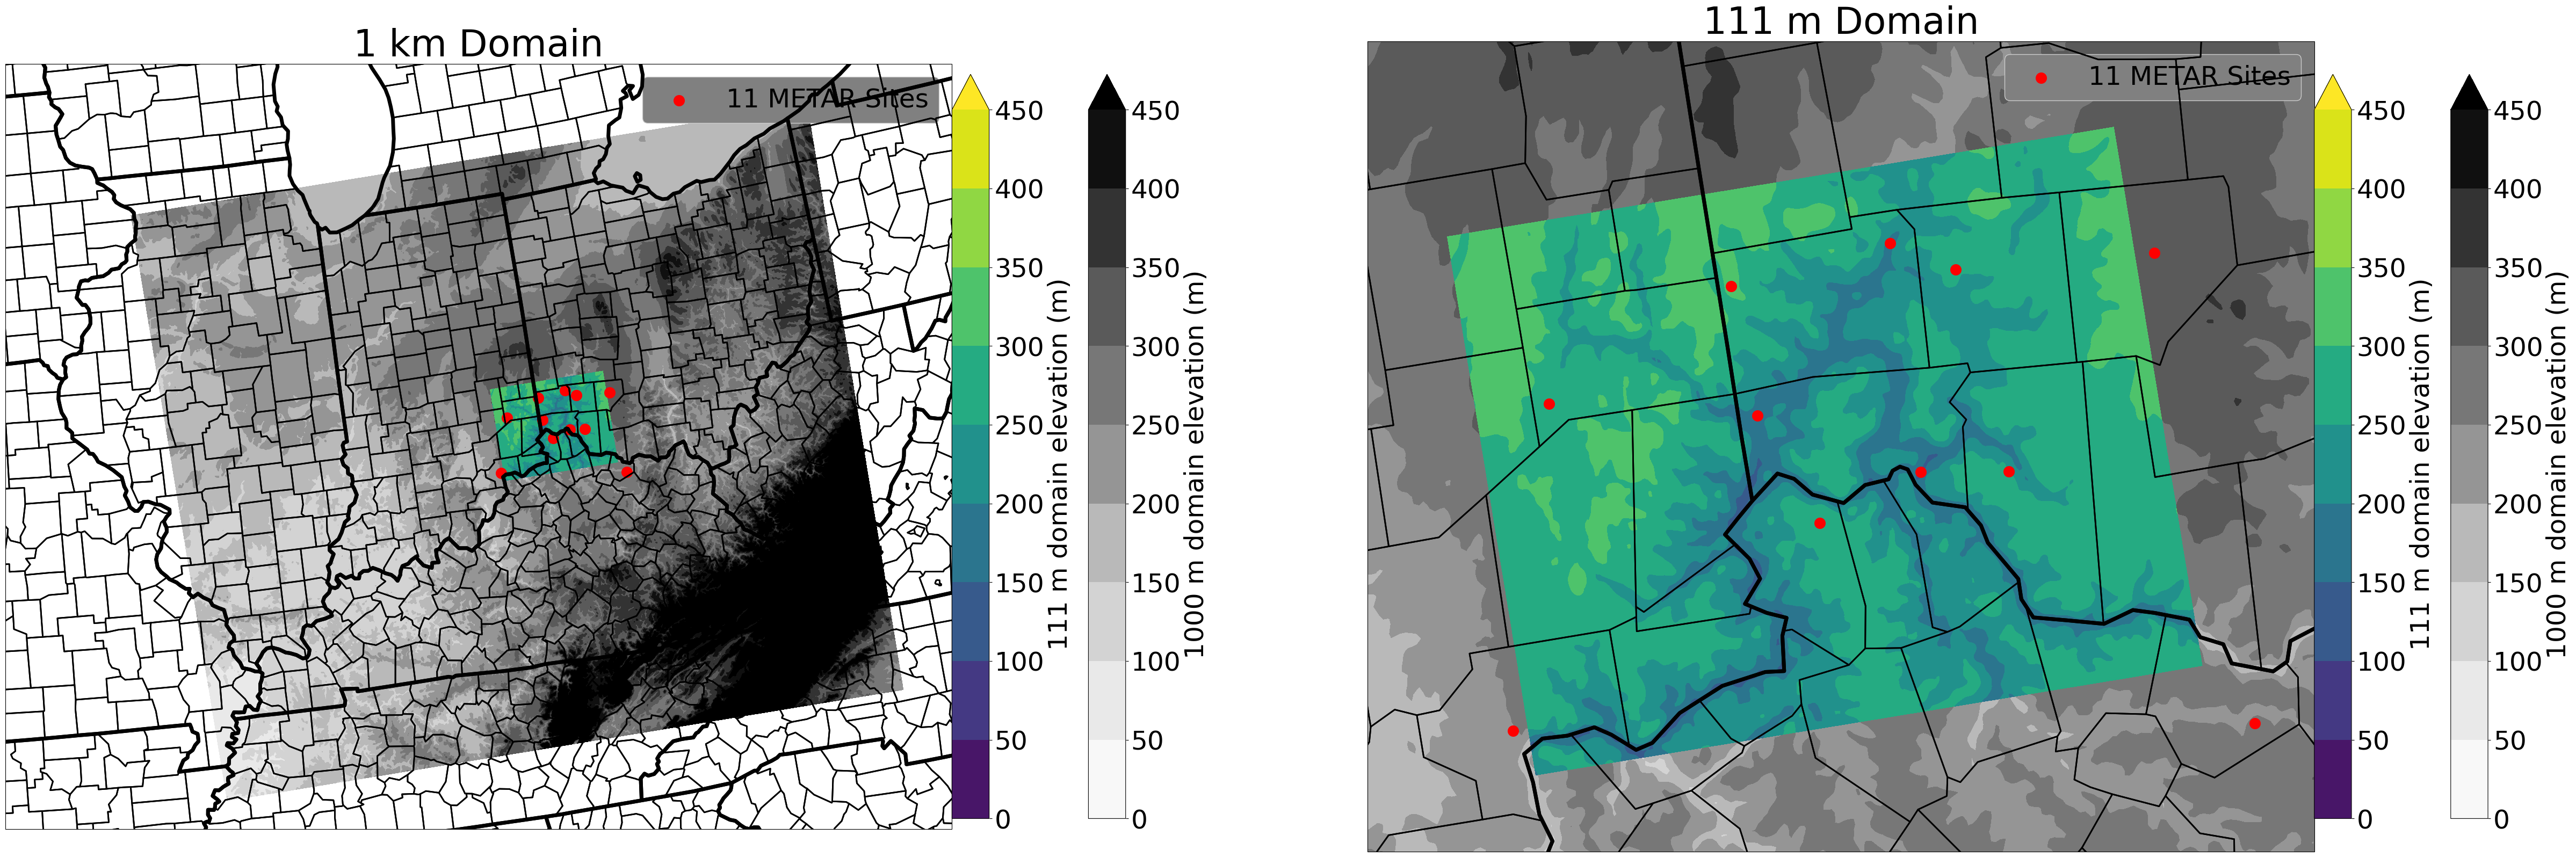

In [17]:
#Make a map to show the domain
lati = 39
loni = -84.00

# lat = 39.4
# lon = -101.80
cenlat1 = float(lati)
cenlon1 = float(loni)

LL1 = (cenlon1-8.,cenlat1-3.5,ccrs.PlateCarree())
UR1 = (cenlon1+4.,cenlat1+3.5,ccrs.PlateCarree())

LL2 = (cenlon1-1.60,cenlat1-0.45,ccrs.PlateCarree())
UR2 = (cenlon1+0.40,cenlat1+0.80,ccrs.PlateCarree())

#Set up our map projection

crs = ccrs.LambertConformal(central_longitude=-100.0, central_latitude=45.0)

#Read in files for state and county boundaries
fname = 'cb_2016_us_county_20m/cb_2016_us_county_20m.shp'
fname2 = 'cb_2016_us_state_20m/cb_2016_us_state_20m.shp'
counties = ShapelyFeature(Reader(fname).geometries(),ccrs.PlateCarree(), facecolor = 'none', edgecolor = 'black')
states = ShapelyFeature(Reader(fname2).geometries(),ccrs.PlateCarree(), facecolor = 'none', edgecolor = 'black')

# Make the plot
# fig=plt.figure(1,figsize=(30, 30))
# ax = plt.subplot(111,projection=crs)

figure_mosaic = """
AB
"""

fig, axes = plt.subplot_mosaic(mosaic=figure_mosaic, figsize=(60,30), subplot_kw={'projection': crs})


plt.sca(axes['A'])
axes['A'].add_feature(counties, edgecolor = 'k', linewidth = 2.0, zorder=20)
axes['A'].add_feature(states, edgecolor = 'k', linewidth = 5.0, zorder=20)

axes['A'].set_extent([LL1[0],UR1[0],LL1[1],UR1[1]])

#Outer domain
cb = plt.contourf(lon[0,:,:], lat[0,:,:], hgt[0,:,:], np.arange(0,500,50), cmap=plt.cm.Greys, transform=ccrs.PlateCarree(), extend='max')

#Inner domain
cn = plt.contourf(lon2[0,:,:], lat2[0,:,:], hgt2[0,:,:], np.arange(0,500,50), cmap=plt.cm.viridis, transform=ccrs.PlateCarree(), extend='max')

plt.scatter(Obs_lon[0,:], Obs_lat[0,:],s=200, c='r',transform=ccrs.PlateCarree(),label='11 METAR Sites')

cg = plt.colorbar(cb, shrink = .6, pad = 0.08, fraction=0.046)
cg.ax.tick_params(labelsize=35)
cg.set_label("1000 m domain elevation (m)",size = 35)

cb = plt.colorbar(cn, shrink = .6, pad = 0.00,fraction=0.046)
cb.ax.tick_params(labelsize=35)
cb.set_label("111 m domain elevation (m)",size = 35)

plt.legend(fontsize=35,facecolor='gray',framealpha=1)
plt.title('1 km Domain', size=50)

plt.sca(axes['B'])
axes['B'].add_feature(counties, edgecolor = 'k', linewidth = 2.0, zorder=20)
axes['B'].add_feature(states, edgecolor = 'k', linewidth = 5.0, zorder=20)

axes['B'].set_extent([LL2[0],UR2[0],LL2[1],UR2[1]])

#Outer domain
cb = plt.contourf(lon[0,:,:], lat[0,:,:], hgt[0,:,:], np.arange(0,500,50), cmap=plt.cm.Greys, transform=ccrs.PlateCarree(), extend='max')

#Inner domain
cn = plt.contourf(lon2[0,:,:], lat2[0,:,:], hgt2[0,:,:], np.arange(0,500,50), cmap=plt.cm.viridis, transform=ccrs.PlateCarree(), extend='max')

plt.scatter(Obs_lon[0,:], Obs_lat[0,:],s=200, c='r',transform=ccrs.PlateCarree(),label='11 METAR Sites')

cg = plt.colorbar(cb, shrink = .6, pad = 0.08, fraction=0.046)
cg.ax.tick_params(labelsize=35)
cg.set_label("1000 m domain elevation (m)",size = 35)

cb = plt.colorbar(cn, shrink = .6, pad = 0.00,fraction=0.046)
cb.ax.tick_params(labelsize=35)
cb.set_label("111 m domain elevation (m)",size = 35)

plt.title('',size=100)

plt.legend(fontsize=35,facecolor='gray',framealpha=1)
plt.title('111 m Domain', size=50)

#plt.savefig('NewDomainComp.png', bbox_inches='tight')

In [18]:
print(np.mean(lon[0,:,:]))
print(np.mean(lat[0,:,:]))

-85.200005
38.917404


In [24]:
print(hgt[0,st_xind, st_yind])
print(elev*units('ft').to('m'))

print(hgt[0,st_xind, st_yind]-elev*units('ft').to('m'))

[260.1366  148.67825 251.08896 173.95557 264.0193  314.50116 294.90262
 244.58078 325.40363 197.65422 263.1216 ]
[262.128 146.91359999999997 256.9464 178.00319999999996 301.44719999999995 317.29679999999996 297.17999999999995 249.63119999999998 327.96479999999997 197.81519999999998 277.97759999999994] meter
[ -1.99140332   1.76465317  -5.85744126  -4.04763359 -37.42791289
  -2.79564033  -2.27738159  -5.05041997  -2.56117451  -0.16097942
 -14.85598745]


In [ ]:
# #Write code to get data from the nearest grid point to a lat/lon point
# grid = pyresample.geometry.GridDefinition(lats=lat[0,:,:], lons=lon[0,:,:])
# # Define some sample points
# # my_lats = np.array([39.29, 45.36, 41.88])
# # my_lons = np.array([-76.61, -71.05, -87.63])

# my_lats = lat_list1
# my_lons = lon_list1
# swath = pyresample.geometry.SwathDefinition(lons=my_lons, lats=my_lats)
# _, _, index_array, distance_array = pyresample.kd_tree.get_neighbour_info(
#     source_geo_def=grid, target_geo_def=swath, radius_of_influence=500000,
#     neighbours=1)
# index_array_2d = np.unravel_index(index_array, grid.shape)
# print(index_array_2d)